In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp

#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])
plt.rcParams['font.size'] = 18
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

colors = ["#FF3E3E","#FF964F","#1982C4","black"]


In [8]:



colors = ["#FF3E3E","#FF964F","#1982C4","black"]

k = 20
taus = np.arange(0,297)*10
seeds = np.arange(1,50+1)
E = 50
tau_e = 1
dci= 0


In [9]:
def make_plot(
        label_IG_X_to_Y = "",
        label_IG_Y_to_X = "",
        xlim = 10,
        nseed = 50,
        name_tpl = ''
):

    Data = np.loadtxt("02_50times_300K_1atm/Dipole_ref_1st_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4] 
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')


    time_Emb_tau = E * 0.01

    plt.figure(figsize=(8,5))

    plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label=f"Dipole: {label_IG_X_to_Y}", 
            alpha=0.5, linewidth=2, color=colors[0])
    plt.plot(taus_plot  , gain_Y_to_X_avg, '-', label=f"Dipole: {label_IG_Y_to_X}",
            alpha=0.5, linewidth=2, color=colors[1])

    plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[0], markersize=5)
    plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
            's', color=colors[1], markersize=4)

    plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[0], lw = 0)
    plt.fill_between(taus_plot  , gain_Y_to_X_avg - error_Y_to_X, 
                                    gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[1], lw = 0)
    
    Data = np.loadtxt("06_SDIG_50times_300K_1atm/Dist_ref_1st_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4]
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')

    plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label=f"Distance: {label_IG_X_to_Y}", 
            alpha=0.5, linewidth=2, color=colors[2])
    plt.plot(taus_plot  , gain_Y_to_X_avg, '-', label=f"Distance: {label_IG_Y_to_X}",
            alpha=0.5, linewidth=2, color=colors[3])

    plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[2], markersize=5)
    plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
            's', color=colors[3], markersize=4)

    plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[2], lw = 0)
    plt.fill_between(taus_plot  , gain_Y_to_X_avg - error_Y_to_X, 
                                    gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[3], lw = 0)

    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"Room Temp: $E = {E}$, $\\tau_e = {time_Emb_tau}$ ps, $k = {k}, Nseed = {nseed}, dci = {dci}$")
    #plt.title(f"LD")
    plt.xlabel("$\\tau$ [ps]")
    plt.ylabel("Imbalance Gain [%]")
    plt.xlim([-0.5, xlim])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(f"{name_tpl}_Imb-Gain.png")
    plt.show()
    plt.close()



### ref dipole vs 1st shell

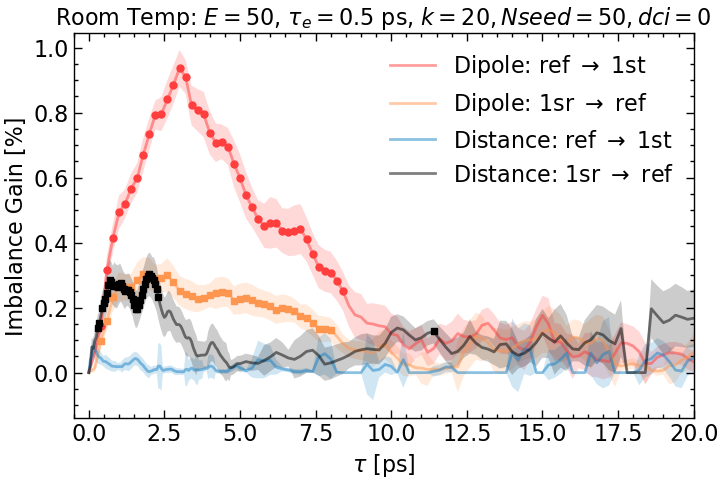

In [10]:
label_IG_X_to_Y = "ref $\\rightarrow$ 1st"
label_IG_Y_to_X = "1sr $\\rightarrow$ ref"



make_plot(label_IG_X_to_Y,
          label_IG_Y_to_X,
          nseed = len(seeds),
          name_tpl = f"ref_1st_300K_1B_200ns_E{E}_k{k}_dci{dci}",
          xlim = 20)

In [15]:
def make_plot(
        label_IG_X_to_Y = "",
        label_IG_Y_to_X = "",
        xlim = 10,
        nseed = 50,
        name_tpl = ''
):

    time_Emb_tau = E * 0.01

    mu = r"\mathrm{\boldsymbol{\mu}}"
    plt.figure(figsize=(8,5))

    plt.ylim((-0.1,1.5))

    # plt.plot(taus_plot  , gain_Y_to_X_avg, '-', label=f"Dipole: {label_IG_Y_to_X}",
    #         alpha=0.5, linewidth=2, color='grey')

    # plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
    #         'o', color=colors[0], markersize=5)
    # plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
    #         's', color=colors[1], markersize=4)

    # plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
    #                                 gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[0], lw = 0)
    # plt.fill_between(taus_plot  , gain_Y_to_X_avg - error_Y_to_X, 
    #                                 gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[1], lw = 0)
    
    Data = np.loadtxt("06_SDIG_50times_300K_1atm/Dist_ref_1st_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4]
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')

    # plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label=f"Distance: {label_IG_X_to_Y}", 
    #         alpha=0.5, linewidth=2, color=colors[2])
    plt.plot(taus_plot  , gain_Y_to_X_avg, '-', label=r"${d}^*_{1st} \rightarrow {d}^*_{ref}$",
            alpha=1, linewidth=2, color=colors[3])

    # plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
    #         'o', color=colors[2], markersize=5)
    plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
            's', color=colors[3], markersize=4)

    # plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
    #                                 gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[2], lw = 0)
    plt.fill_between(taus_plot  , gain_Y_to_X_avg - error_Y_to_X, 
                                    gain_Y_to_X_avg + error_Y_to_X, alpha=0.3, color=colors[3], lw = 0)


    Data = np.loadtxt("09_Distance_Dipole_cross_IG/distance1st_dipoleref_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4]
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')

    # plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label=f"Distance: {label_IG_X_to_Y}", 
    #         alpha=0.5, linewidth=2, color=colors[2])
    plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"${d}^*_{1st} \rightarrow " + mu + r"_{ref}$",
            alpha=1, linewidth=2, color=colors[0])

    plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[0], markersize=5)
    # plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
    #         's', color=colors[0], markersize=4)

    plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.3, color=colors[0], lw = 0)
    # plt.fill_between(taus_plot  , gain_Y_to_X_avg - error_Y_to_X, 
    #                                 gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[0], lw = 0)
    
    Data = np.loadtxt("09_Distance_Dipole_cross_IG/distance1st_dipole1st_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4]
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')

    # plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label=f"Distance: {label_IG_X_to_Y}", 
    #         alpha=0.5, linewidth=2, color=colors[2])
    plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"${d}^*_{1st} \rightarrow " + mu + r"_{1st}$",
            alpha=1, linewidth=2, color=colors[1], linestyle = "-.")

    plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[1], markersize=5)
    # plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
    #         's', color=colors[0], markersize=4)

    plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.3, color=colors[1], lw = 0)
    # plt.fill_between(taus_plot  , gain_Y_to_X_avg - error_Y_to_X, 
    #                                 gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[0], lw = 0)
    
    Data = np.loadtxt("09_Distance_Dipole_cross_IG/distance1st_dipole2nd_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4]
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')

    # plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label=f"Distance: {label_IG_X_to_Y}", 
    #         alpha=0.5, linewidth=2, color=colors[2])
    plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"${d}^*_{1st} \rightarrow " + mu + r"_{2nd}$",
            alpha=1, linewidth=2, color=colors[2], linestyle = "--")

    plt.plot(taus_plot[mask_X_to_Y]  , gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[2], markersize=5)
    # plt.plot(taus_plot[mask_Y_to_X]  , gain_Y_to_X_avg[mask_Y_to_X], 
    #         's', color=colors[0], markersize=4)

    # plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_X_to_Y, 
    #                                 gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[2], lw = 0)
    plt.fill_between(taus_plot  , gain_X_to_Y_avg - error_Y_to_X, 
                                    gain_X_to_Y_avg + error_Y_to_X, alpha=0.3, color=colors[2], lw = 0)

    # TIME REFERENCE FOMR mu to mu 

    Data = np.loadtxt("02_50times_300K_1atm/Dipole_ref_1st_300K_1B_200ns_E50_k20_dci0_Imb-Gain.dat")
    taus_plot = Data[:,0]
    gain_X_to_Y_avg = Data[:,1]
    error_X_to_Y = Data[:,2]
    mask_X_to_Y = Data[:,3].astype('bool')
    gain_Y_to_X_avg = Data[:,4] 
    error_Y_to_X = Data[:,5]
    mask_Y_to_X = Data[:,6].astype('bool')


    plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"$" + mu + r"_{ref} \rightarrow" + mu + r"_{1st}$", 
            alpha=1, linewidth=2, color='grey', linestyle=':')

    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"Room Temperature")
    #plt.title(f"LD")
    plt.xlabel("$\\tau$ [ps]")
    plt.ylabel("IG [%]")
    plt.xlim([-0.5, xlim])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.grid()
    plt.savefig(f"{name_tpl}_Imb-Gain.png",dpi=300)
    plt.savefig(f"{name_tpl}_Imb-Gain.pdf",dpi=300)
    plt.show()
    plt.close()



/tmp/ipykernel_32312/595505789.py:89: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"${d}^*_{1st} \rightarrow " + mu + r"_{1st}$",
/tmp/ipykernel_32312/595505789.py:113: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"${d}^*_{1st} \rightarrow " + mu + r"_{2nd}$",
/tmp/ipykernel_32312/595505789.py:138: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(taus_plot  , gain_X_to_Y_avg, '-', label= r"$" + mu + r"_{ref} \rightarrow" + mu + r"_{1st}$",


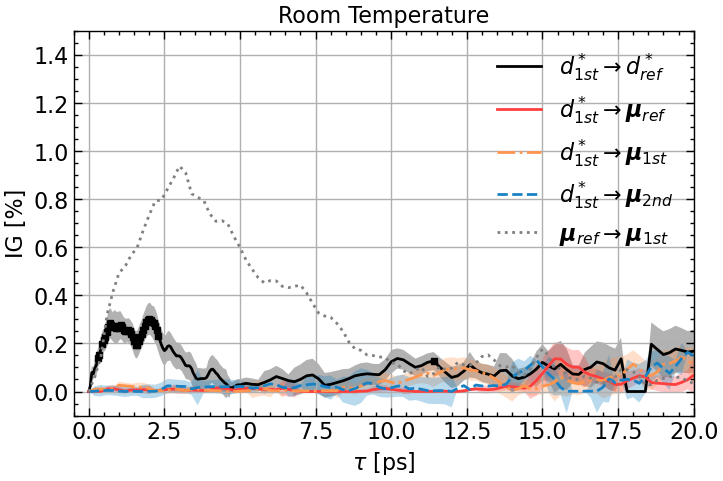

In [16]:
label_IG_X_to_Y = "ref $\\rightarrow$ 1st"
label_IG_Y_to_X = "1sr $\\rightarrow$ ref"



make_plot(label_IG_X_to_Y,
          label_IG_Y_to_X,
          name_tpl = f"Cross-IG-Evaluation_E{E}_k{k}_dci{dci}",
          xlim = 20)